# week 4: Statistics and Exploratory Data Analysis (EDA)
Dataset: 'diabetes_risk_clean.csv' (from week 2)

#Objective
 Explore the cleaned diabetes datasets using descriptive statistics and visualization.
 Analyze single variables (Univariate Analysis).
 Discover relationships betweeen variables (Bivariate Analysis)
 Run an introductory hypothesis test (T-Test)
 Document key findings and findings to inform future predictive modeling

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a nice visual style for our plots
sns.set_theme(style="whitegrid")

# Load the cleaned dataset from Week 2
# Note: You may need to change the path if your folder structure is different
df = pd.read_csv('../week2_data_cleaning/diabetes_risk_clean.csv')

print("Shape:", df.shape)
print("\nSummary Statistics:")
display(df.describe())

print("\nData Types:")
print(df.dtypes)

Matplotlib is building the font cache; this may take a moment.


Shape: (15000, 22)

Summary Statistics:


,patient_id,age,bmi,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,pulse_pressure
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,44.333667,23.062260,7.309860,5.941200,168.789933,6.878387,139.496200,86.256933,100.207933,53.239267
std,4330.271354,10.383753,4.046391,1.109372,2.148406,38.365822,0.843276,12.660785,8.386529,10.760331,13.100722
min,1.000000,18.000000,15.000000,3.000000,1.000000,72.000000,4.800000,80.000000,50.000000,73.200000,-10.000000
25%,3750.750000,38.000000,20.100000,6.700000,4.000000,145.000000,6.300000,130.000000,80.000000,92.500000,44.000000
50%,7500.500000,45.000000,22.700000,7.000000,6.000000,165.000000,6.800000,140.000000,88.000000,99.300000,52.000000
75%,11250.250000,52.000000,25.600000,8.000000,7.000000,189.000000,7.300000,150.000000,90.000000,106.900000,61.000000
max,15000.000000,80.000000,40.800000,12.000000,10.000000,400.000000,13.400000,200.000000,120.000000,148.200000,102.000000



Data Types:
patient_id                    int64
age                           int64
gender                          str
city                            str
bmi                         float64
family_history_diabetes         str
physical_activity_level         str
diet_type                       str
smoking_status                  str
alcohol_consumption             str
hours_sleep_per_night       float64
stress_level                  int64
fasting_blood_sugar           int64
hba1c_level                 float64
blood_pressure_systolic       int64
blood_pressure_diastolic      int64
waist_circumference_cm      float64
income_bracket                  str
diabetes_risk                   str
pulse_pressure                int64
bmi_category                    str
age_group                       str
dtype: object


#Data Loading and inspection 
Load the dataset and inspect its structure 
confirm data types,check the summary statistics (mean,median,standard deviation),and ensure there are no missing values

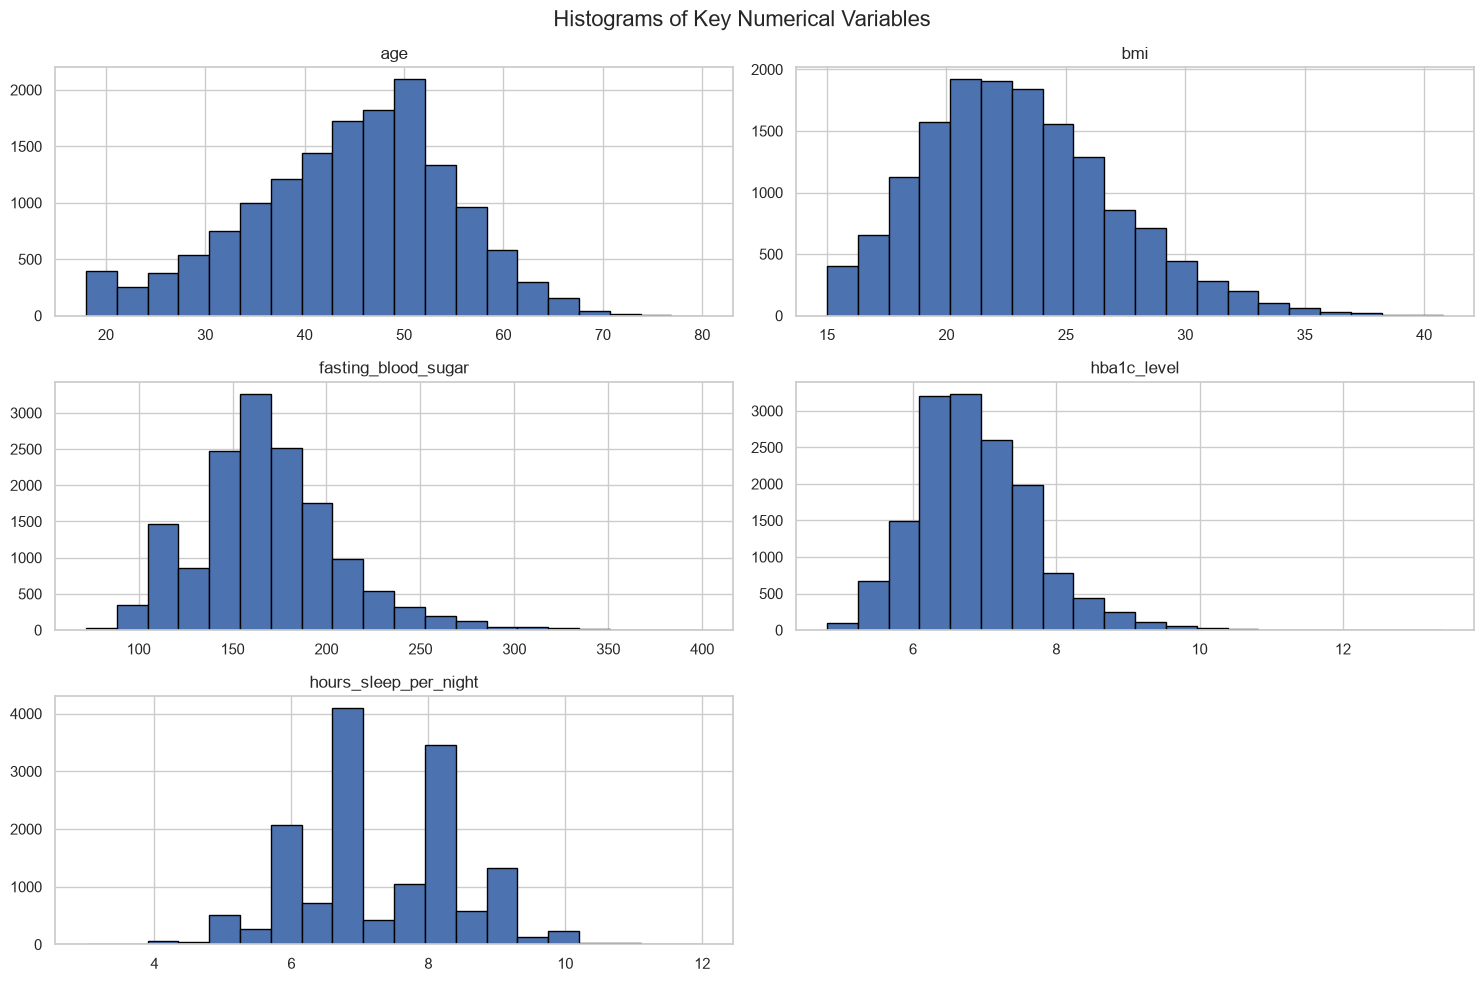

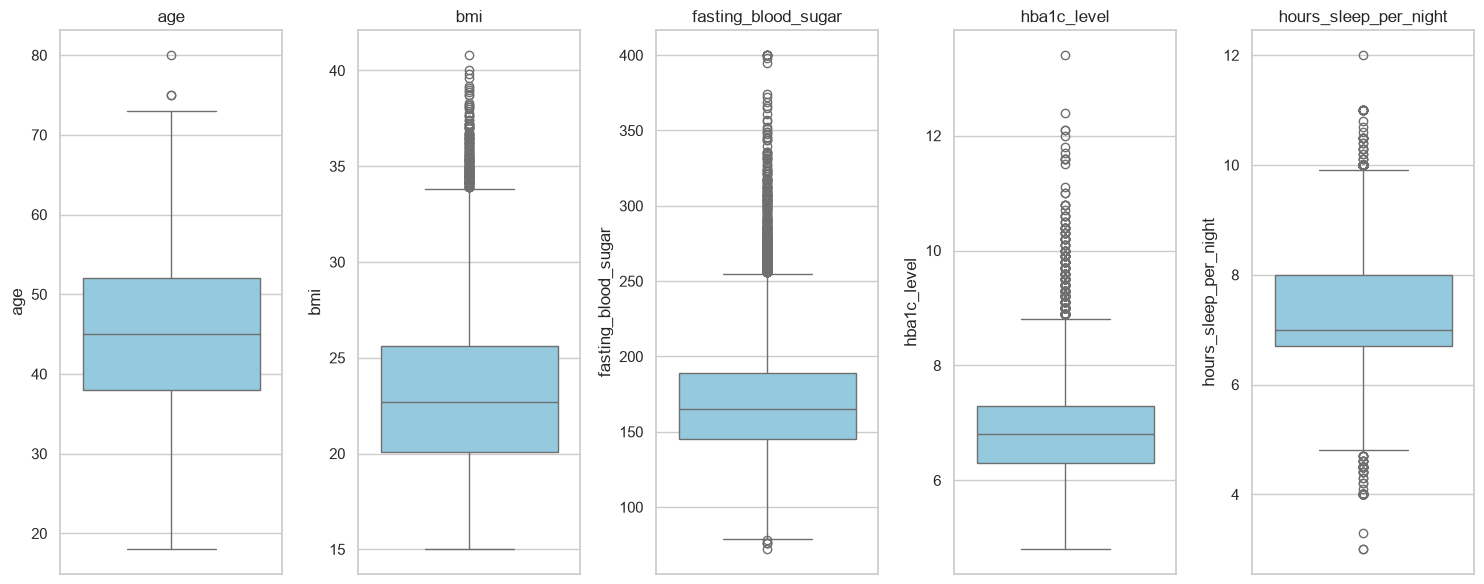

In [ ]:
# Select some key numerical columns
num_cols = ['age', 'bmi', 'fasting_blood_sugar', 'hba1c_level', 'hours_sleep_per_night']

# Create histograms
df[num_cols].hist(figsize=(15, 10), bins=20, edgecolor='black')
plt.suptitle("Histograms of Key Numerical Variables", fontsize=16)
plt.tight_layout()
plt.show()

# Create box plots to spot outliers
plt.figure(figsize=(15, 6))
for i, col in enumerate(num_cols):
    plt.subplot(1, 5, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.show()

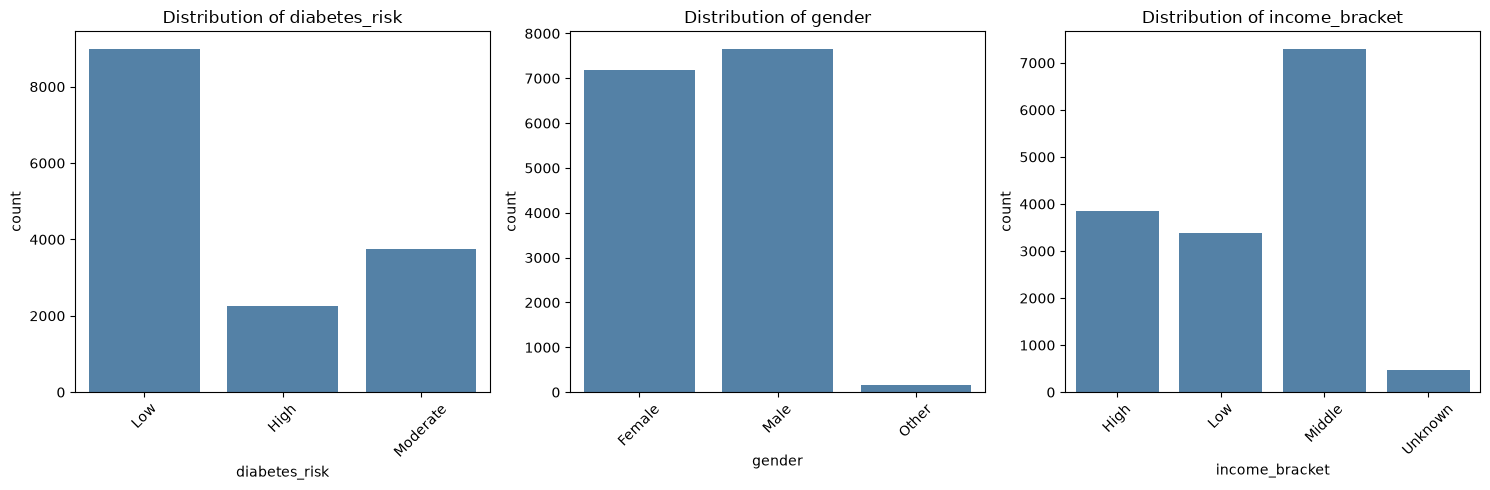

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

if 'df' not in globals():
    df = pd.read_csv('../week2_data_cleaning/diabetes_risk_clean.csv')

cat_cols = ['diabetes_risk', 'gender', 'income_bracket']

plt.figure(figsize=(15, 5))
for i, col in enumerate(cat_cols):
    plt.subplot(1, 3, i+1)
    sns.countplot(data=df, x=col, color='steelblue')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Bivariate Analysis (Relationships Between Variables)

To see how variables interact with each other.
*   **Correlation Heatmap:** calculate the Pearson correlation coefficient for all numerical columns. This helps identify highly correlated features (which is useful for feature selection later).
*   **Box Plots (Target vs. Features):** visualize how `bmi` and `fasting_blood_sugar` differ across the target variable (`diabetes_risk`). This helps me understand which features are strong indicators of diabetes risk.

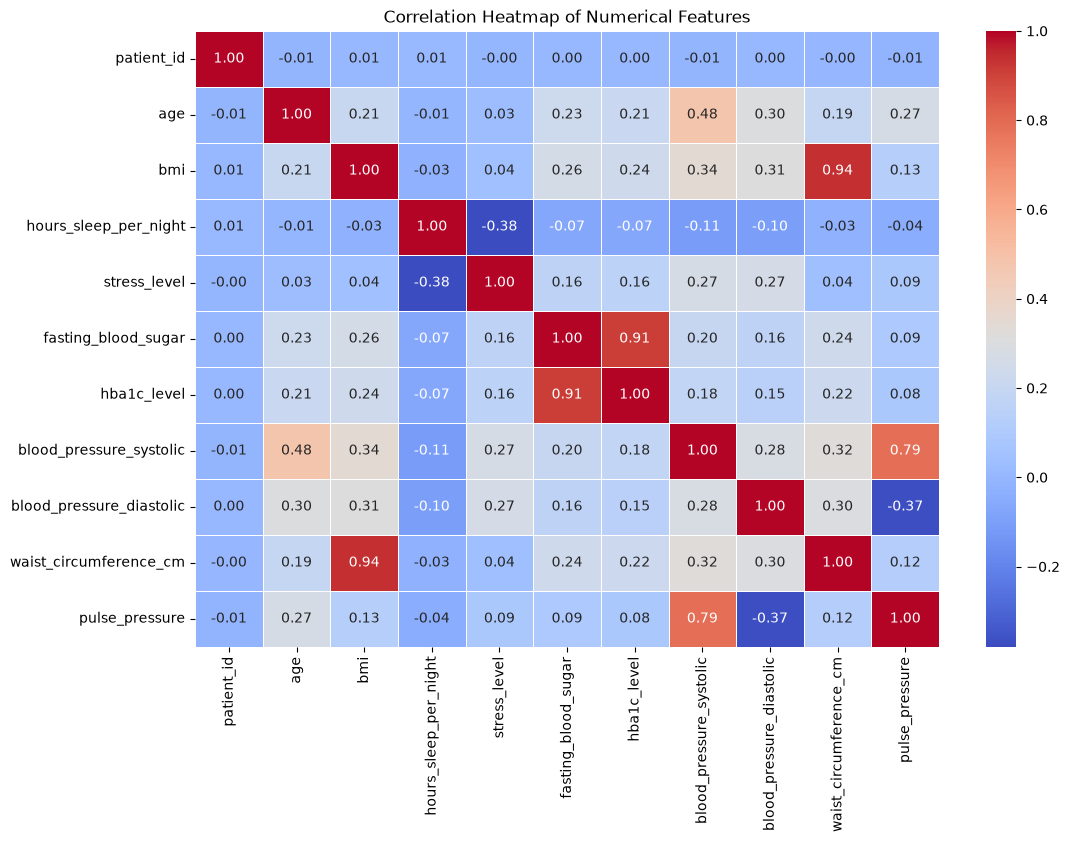

In [7]:
# Calculate the correlation matrix for numerical columns
plt.figure(figsize=(12, 8))

# Select only numerical columns for correlation
numerical_df = df.select_dtypes(include='number')
corr_matrix = numerical_df.corr()

# Create a heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

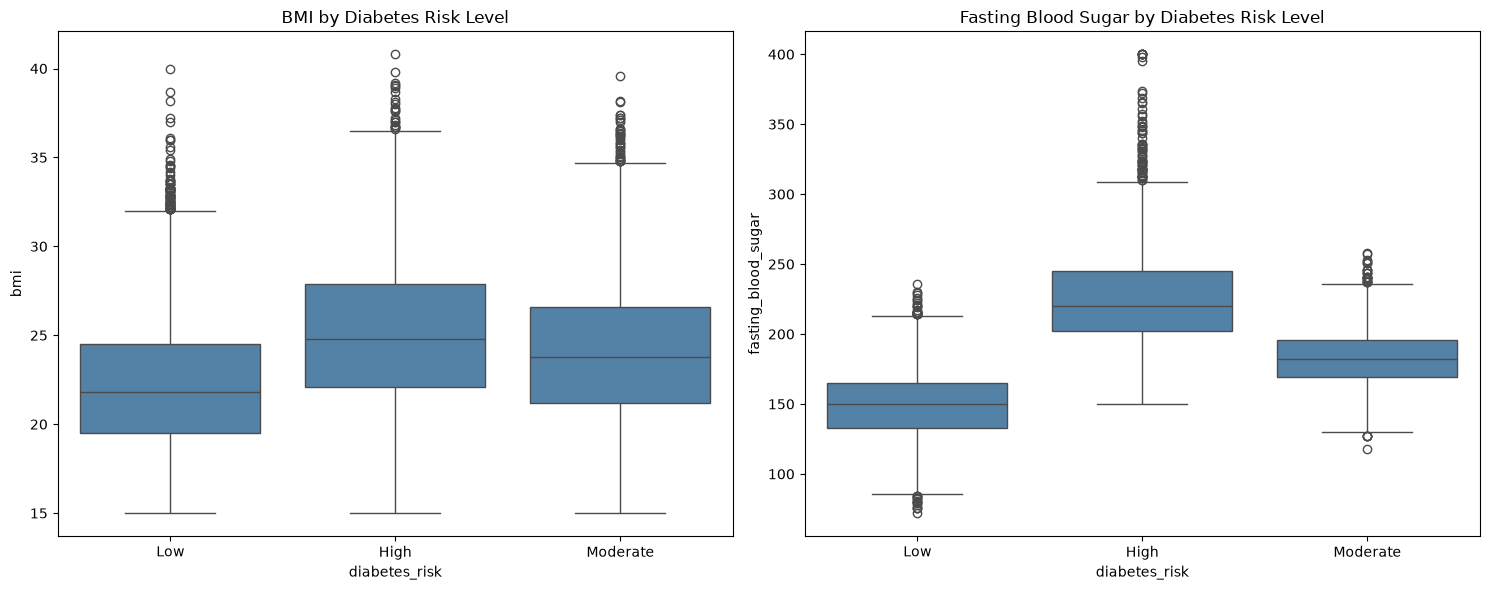

In [9]:
# Let's see how BMI and Fasting Blood Sugar change across Diabetes Risk levels
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=df, x='diabetes_risk', y='bmi', ax=axes[0], color='steelblue')
axes[0].set_title('BMI by Diabetes Risk Level')

sns.boxplot(data=df, x='diabetes_risk', y='fasting_blood_sugar', ax=axes[1], color='steelblue')
axes[1].set_title('Fasting Blood Sugar by Diabetes Risk Level')

plt.tight_layout()
plt.show()

# 4. Introductory Hypothesis Testing

Visualizations give us clues, but statistics prove if those clues are real. 
Run an **Independent T-Test** to compare the average BMI of patients in the `Low` risk category versus those in the `High` risk category.

**Hypotheses:**
*   **Null Hypothesis (H0):** There is no significant difference in the mean BMI between the Low and High diabetes risk groups.
*   **Alternative Hypothesis (H1):** There is a significant difference in the mean BMI between the Low and High diabetes risk groups.

Use a significance level of **alpha = 0.05**. If the p-value is less than 0.05, we reject the null hypothesis.

In [10]:
from scipy import stats

# compare the average BMI of people with Low risk vs High risk
low_risk_bmi = df[df['diabetes_risk'] == 'Low']['bmi']
high_risk_bmi = df[df['diabetes_risk'] == 'High']['bmi']

# Perform an independent t-test
t_stat, p_value = stats.ttest_ind(low_risk_bmi, high_risk_bmi, nan_policy='omit')

print(f"Average BMI (Low Risk): {low_risk_bmi.mean():.2f}")
print(f"Average BMI (High Risk): {high_risk_bmi.mean():.2f}")
print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("\nConclusion: There is a statistically significant difference in BMI between the two groups (p < 0.05).")
else:
    print("\nConclusion: There is no statistically significant difference in BMI between the two groups (p >= 0.05).")

Average BMI (Low Risk): 22.13
Average BMI (High Risk): 25.11
T-statistic: -33.15
P-value: 0.0000

Conclusion: There is a statistically significant difference in BMI between the two groups (p < 0.05).


# EDA Summary & Findings

# 1. Key Patterns
- **Age & BMI:** The population leans towards older adults and higher BMI categories.
- **Target Variable:** The majority of patients fall into the 'Low' diabetes risk category, followed by 'Moderate' and 'High'.
- **Missing Data:** Handled in Week 2; no missing values remain.

# 2. Relationships Identified
- **Correlation:** There is a strong positive correlation between `fasting_blood_sugar` and `hba1c_level`, which is medically expected.
- **Risk Factors:** Box plots show that patients with 'High' diabetes risk tend to have significantly higher BMI and fasting blood sugar compared to 'Low' risk patients.
- **Hypothesis Test:** The t-test confirmed that the difference in BMI between Low and High risk groups is statistically significant (p < 0.05).

# 3. Questions for Further Analysis
- Can we build a classification model to predict `diabetes_risk` based on the strong features we found?
- Are there interactions between `physical_activity_level` and `diet_type` that affect risk more than either alone?